# 🌦️ Sounding Atmosfer (Jerukagung Meteorologi - UTC)
Notebook ini memfasilitasi pengunduhan data profil sounding atmosfer **Waktu Standar Radiosonde (00:00 UTC / 12:00 UTC)** dari API Open-Meteo, memproses parameter termodinamika menggunakan **MetPy**, serta memvisualisasikan diagram **Skew-T Log-P**

In [1]:
# ========================================================
# 1. PENGATURAN LOKASI & WAKTU STANDAR RADIOSONDE (UTC)
# ========================================================
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import metpy.calc as mpcalc
from metpy.units import units
from metpy.plots import SkewT

# --------------------------------------------------------
# CONFIG: WAKTU SOUNDING RADIOSONDE STANDAR (UTC)
# Set TARGET_DATE = None untuk hari ini secara otomatis
# Atau isi format "YYYY-MM-DD" (misal: "2026-08-04")
# Pilihan TARGET_UTC_HOUR:
#   0  -> 00:00 UTC (07:00 WIB / 7 Pagi)
#   12 -> 12:00 UTC (19:00 WIB / 7 Malam)
# --------------------------------------------------------
TARGET_DATE = None  
TARGET_UTC_HOUR = 0  # 00:00 UTC

# Koordinat Lokasi Target (Jerukagung / Kebumen)
LATITUDE = -7.736663290223948
LONGITUDE = 109.64605763039752
LOCATION_NAME = "Kebumen"

# Level Tekanan Udara (hPa) Atmosfer Vertikal
PRESSURES = [1000, 975, 950, 925, 900, 850, 800, 700, 600, 500, 400, 300, 250, 200, 150, 100]

# Menyusun Parameter Variabel API Open-Meteo
hourly_vars = []
for p in PRESSURES:
    hourly_vars.extend([
        f"temperature_{p}hPa", f"relative_humidity_{p}hPa",
        f"wind_speed_{p}hPa", f"wind_direction_{p}hPa"
    ])

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "hourly": ",".join(hourly_vars),
    "timezone": "UTC"
}

print(f"[INFO] Mengunduh data sounding Open-Meteo jam {TARGET_UTC_HOUR:02d}:00 UTC untuk {LOCATION_NAME}...")
res = requests.get(url, params=params).json()
hourly = res["hourly"]

# Match Jam & Tanggal Target (Standar UTC)
times = pd.to_datetime(hourly["time"])
if TARGET_DATE is None:
    today_str = pd.Timestamp.now(tz="UTC").strftime("%Y-%m-%d")
    target_dt = pd.to_datetime(f"{today_str} {TARGET_UTC_HOUR:02d}:00")
else:
    target_dt = pd.to_datetime(f"{TARGET_DATE} {TARGET_UTC_HOUR:02d}:00")

target_hour_idx = int(np.abs(times - target_dt).argmin())
time_valid_str = f"{hourly['time'][target_hour_idx].replace('T', ' ')} UTC"

temp_list, rh_list, ws_list, wd_list = [], [], [], []
for p in PRESSURES:
    temp_list.append(hourly[f"temperature_{p}hPa"][target_hour_idx])
    rh_list.append(hourly[f"relative_humidity_{p}hPa"][target_hour_idx])
    ws_list.append(hourly[f"wind_speed_{p}hPa"][target_hour_idx])
    wd_list.append(hourly[f"wind_direction_{p}hPa"][target_hour_idx])

print(f"[SUCCESS] Data sounding berhasil diunduh! Waktu Observation: {time_valid_str}")

[INFO] Mengunduh data sounding Open-Meteo jam 00:00 UTC untuk Kebumen...
[SUCCESS] Data sounding berhasil diunduh! Waktu Observation: 2026-08-05 00:00 UTC


## 2. Pemrosesan Termodinamika MetPy

In [2]:
# ========================================================
# 2. PEMROSESAN TERMODINAMIKA METPY (SUHU, WETBULB & PARCEL)
# ========================================================
# Konversi ke Float Array (Aman dari NoneType)
p_raw = np.array(PRESSURES, dtype=float) * units.hPa
T_raw = np.array(temp_list, dtype=float) * units.degC
rh_raw = np.array(rh_list, dtype=float) * units.percent
ws_raw = np.array(ws_list, dtype=float) * units('km/h')
wd_raw = np.array(wd_list, dtype=float) * units.degrees

# Filter Layer Valid (Abaikan jika ada NaN)
valid_mask = ~np.isnan(T_raw.m) & ~np.isnan(rh_raw.m)
p_arr = p_raw[valid_mask]
T_arr = T_raw[valid_mask]
rh_arr = rh_raw[valid_mask]
ws_arr = ws_raw[valid_mask]
wd_arr = wd_raw[valid_mask]

# Hitung Vektor Angin (U & V Knots)
u_arr, v_arr = mpcalc.wind_components(ws_arr.to(units.knots), wd_arr)

# Hitung Dewpoint (Td) & Wetbulb (Tw)
Td_arr = mpcalc.dewpoint_from_relative_humidity(T_arr, rh_arr)
Tw_arr = mpcalc.wet_bulb_temperature(p_arr, T_arr, Td_arr)

# Mixed-Layer Parcel Path (100hPa depth)
try:
    ml_p, ml_t, ml_td = mpcalc.mixed_parcel(p_arr, T_arr, Td_arr, depth=100 * units.hPa)
    ml_prof = mpcalc.parcel_profile(p_arr, ml_t, ml_td)
except Exception:
    ml_prof = mpcalc.parcel_profile(p_arr, T_arr[0], Td_arr[0])

# Precipitable Water (PWAT)
pwat = mpcalc.precipitable_water(p_arr, Td_arr)

# LCL
try:
    lcl_p, lcl_t = mpcalc.lcl(p_arr[0], T_arr[0], Td_arr[0])
except Exception:
    lcl_p, lcl_t = np.nan * units.hPa, np.nan * units.degC

# CAPE & CIN
try:
    sb_cape, sb_cin = mpcalc.surface_based_cape_cin(p_arr, T_arr, Td_arr)
except Exception:
    sb_cape, sb_cin = 0 * units("J/kg"), 0 * units("J/kg")

try:
    ml_cape, ml_cin = mpcalc.mixed_layer_cape_cin(p_arr, T_arr, Td_arr)
except Exception:
    ml_cape, ml_cin = 0 * units("J/kg"), 0 * units("J/kg")

try:
    mu_cape, mu_cin = mpcalc.most_unstable_cape_cin(p_arr, T_arr, Td_arr)
except Exception:
    mu_cape, mu_cin = 0 * units("J/kg"), 0 * units("J/kg")

# Indeks K & Total Totals
try:
    ki = mpcalc.k_index(p_arr, T_arr, Td_arr)
except Exception:
    ki = np.nan * units.degC

try:
    tt = mpcalc.total_totals_index(p_arr, T_arr, Td_arr)
except Exception:
    tt = np.nan * units.degC

print(f"[INFO] Waktu Analisis: {time_valid_str}")
print(f"[INFO] PWAT: {pwat.to('in').m:.2f} in ({pwat.to('mm').m:.1f} mm) | SBCAPE: {sb_cape.m:.0f} J/kg | MLCAPE: {ml_cape.m:.0f} J/kg")

[INFO] Waktu Analisis: 2026-08-05 00:00 UTC
[INFO] PWAT: 1.26 in (32.0 mm) | SBCAPE: 0 J/kg | MLCAPE: 0 J/kg


## 3. Visualisasi Skew-T Sounding Diagram (Gaya TropicalTidbits)

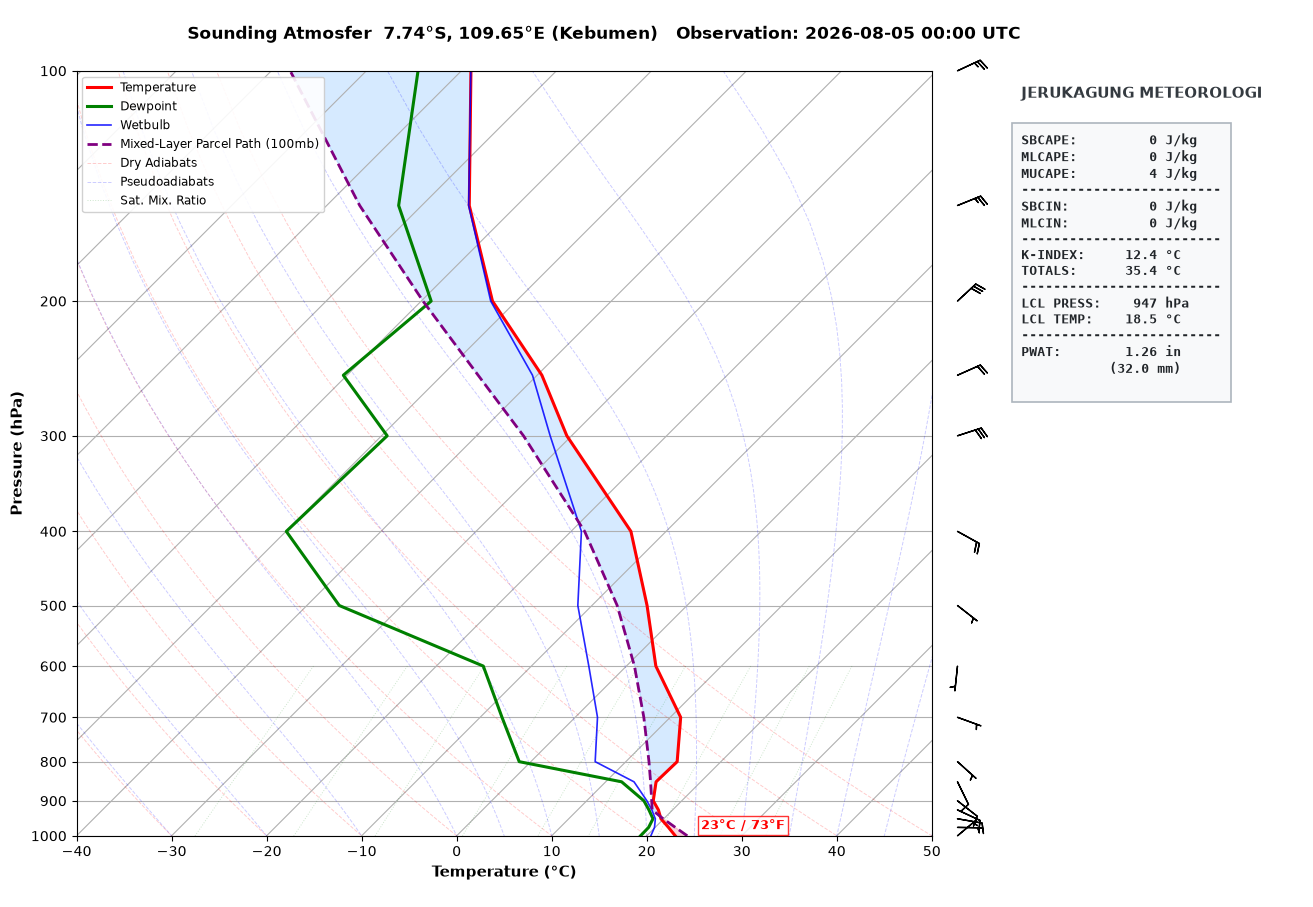

In [3]:
# ========================================================
# 3. VISUALISASI SKEW-T SOUNDING GAYA TROPICALTIDBITS
# ========================================================
fig = plt.figure(figsize=(14, 9), facecolor='#ffffff')
gs = gridspec.GridSpec(1, 2, width_ratios=[3.2, 1.1], wspace=0.12)

# --------------------------------------------------------
# DIAGRAM SKEW-T LOG-P UTAMA
# --------------------------------------------------------
skew = SkewT(fig, rotation=45, subplot=gs[0])

# Plot Kurva Utama (Temperature=Red, Dewpoint=Green, Wetbulb=Blue, ML Parcel=Purple Dashed)
skew.plot(p_arr, T_arr, 'red', linewidth=2.2, label='Temperature')
skew.plot(p_arr, Td_arr, 'green', linewidth=2.2, label='Dewpoint')
skew.plot(p_arr, Tw_arr, 'blue', linewidth=1.2, alpha=0.85, label='Wetbulb')
skew.plot(p_arr, ml_prof.to(units.degC), color='purple', linewidth=2.0, linestyle='--', label='Mixed-Layer Parcel Path (100mb)')

# Plot Vektor Angin (Wind Barbs) di SETIAP Lapisan Tekanan
skew.plot_barbs(p_arr, u_arr, v_arr, xloc=1.03, length=6)

# Garis Referensi Adiabat & Mixing Ratio
skew.plot_dry_adiabats(alpha=0.2, color='brown', linewidth=0.7, label='Dry Adiabats')
skew.plot_moist_adiabats(alpha=0.2, color='blue', linewidth=0.7, label='Pseudoadiabats')
skew.plot_mixing_lines(alpha=0.2, color='green', linewidth=0.7, linestyle=':', label='Sat. Mix. Ratio')

# Shading CAPE & CIN
skew.shade_cape(p_arr, T_arr, ml_prof.to(units.degC), alpha=0.18, color='crimson')
skew.shade_cin(p_arr, T_arr, ml_prof.to(units.degC), alpha=0.18, color='dodgerblue')

# Batas Aksis & Format Text Axis
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 50)
skew.ax.set_xlabel('Temperature (°C)', fontsize=11, fontweight='bold')
skew.ax.set_ylabel('Pressure (hPa)', fontsize=11, fontweight='bold')
skew.ax.legend(loc='upper left', fontsize=8.5, framealpha=0.9, facecolor='#ffffff')

# Badge Suhu Permukaan (Surface T/Td Badge)
surf_t_f = T_arr[0].to('degF').m
skew.ax.text(T_arr[0].m + 2, 980, f"{T_arr[0].m:.0f}°C / {surf_t_f:.0f}°F", 
             color='red', fontweight='bold', fontsize=9.5, bbox=dict(boxstyle='square,pad=0.2', facecolor='#ffffff', edgecolor='red', alpha=0.8))

# --------------------------------------------------------
# PANEL KANAN: TABEL PARAMETER KONVEKSI (JERUKAGUNG METEOROLOGI)
# --------------------------------------------------------
ax_side = fig.add_subplot(gs[1])
ax_side.axis('off')

# Header Watermark Kanan (Lurus Sejajar dengan Kotak Parameter x=0.05)
ax_side.text(0.05, 0.98, 'JERUKAGUNG METEOROLOGI', fontsize=11, fontweight='bold', color='#343a40', ha='left', va='top')

pwat_in = pwat.to('in').m
pwat_mm = pwat.to('mm').m

# Format Teks Kotak Parameter KonveKSI
param_text = (
    f"SBCAPE:    {sb_cape.m:6.0f} J/kg\n"
    f"MLCAPE:    {ml_cape.m:6.0f} J/kg\n"
    f"MUCAPE:    {mu_cape.m:6.0f} J/kg\n"
    "-------------------------\n"
    f"SBCIN:     {sb_cin.m:6.0f} J/kg\n"
    f"MLCIN:     {ml_cin.m:6.0f} J/kg\n"
    "-------------------------\n"
    f"K-INDEX:   {ki.m:6.1f} °C\n"
    f"TOTALS:    {tt.m:6.1f} °C\n"
    "-------------------------\n"
    f"LCL PRESS: {lcl_p.m:6.0f} hPa\n"
    f"LCL TEMP:  {lcl_t.m:6.1f} °C\n"
    "-------------------------\n"
    f"PWAT:      {pwat_in:6.2f} in\n"
    f"           ({pwat_mm:.1f} mm)\n"
)

ax_side.text(0.05, 0.92, param_text, fontsize=9.5, family='monospace', fontweight='bold',
             color='#212529', va='top', bbox=dict(boxstyle='square,pad=0.7', facecolor='#f8f9fa', edgecolor='#adb5bd', linewidth=1.2))

# Header Judul Utama (Observation: [YYYY-MM-DD HH:MM] UTC)
title_header = f"Sounding Atmosfer  {abs(LATITUDE):.2f}°S, {LONGITUDE:.2f}°E ({LOCATION_NAME})   Observation: {time_valid_str}"
fig.suptitle(title_header, fontsize=12, fontweight='bold', x=0.45, y=0.98)

fig.subplots_adjust(left=0.07, right=0.95, top=0.93, bottom=0.08, wspace=0.15)
plt.savefig('Radiosonde.png', dpi=300)
plt.show()